<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unique predicted classes: [0, 1]


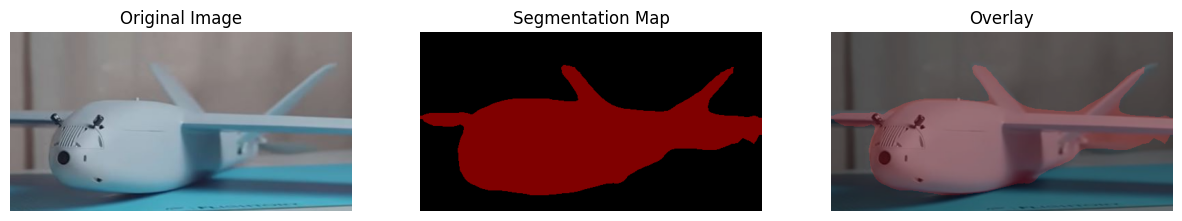

In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load DeepLabV3 with a ResNet-101 backbone pretrained on COCO dataset
model = models.segmentation.deeplabv3_resnet101(pretrained=True)
model.eval()  # Set model to evaluation mode

# Load a random image
image_path = "drone.JPG"
image = Image.open(image_path).convert('RGB')

# Define preprocessing pipeline
preprocess = transforms.Compose([
    transforms.ToTensor(),  # Convert image to Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize as required by the model
])

# Preprocess the image
input_tensor = preprocess(image).unsqueeze(0)  # Add batch dimension

# Perform inference
with torch.no_grad():
    output = model(input_tensor)['out'][0]  # Extract segmentation output

# Map class predictions to colors
def decode_segmentation(mask, num_classes=21):
    # Define color palette for Pascal VOC (21 classes)
    colors = np.array([
        [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0],
        [0, 0, 128], [128, 0, 128], [0, 128, 128], [128, 128, 128],
        [64, 0, 0], [192, 0, 0], [64, 128, 0], [192, 128, 0],
        [64, 0, 128], [192, 0, 128], [64, 128, 128], [192, 128, 128],
        [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
        [0, 64, 128]
    ])

    r = np.zeros_like(mask, dtype=np.uint8)
    g = np.zeros_like(mask, dtype=np.uint8)
    b = np.zeros_like(mask, dtype=np.uint8)

    for cls in range(num_classes):
        idx = mask == cls
        r[idx] = colors[cls, 0]
        g[idx] = colors[cls, 1]
        b[idx] = colors[cls, 2]

    return np.stack([r, g, b], axis=2)


output_predictions = output.argmax(0).cpu()

print("Unique predicted classes:", torch.unique(output_predictions).tolist())

segmentation_map = decode_segmentation(output_predictions.numpy())

image_np = np.array(image.resize((segmentation_map.shape[1], segmentation_map.shape[0])))

overlay = (0.6 * image_np + 0.4 * segmentation_map).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Segmentation Map")
plt.imshow(segmentation_map)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()


# Task 01 - Apply pre-trained model (DeepLabV3_ResNet50) on Segmentation Dataset

Using device: cuda
Train subset: 800
Val subset: 200
Test set: 1000
Model device: cuda:0
Using device: cuda
Model device: cuda:0
Train batches: 50
Val batches: 13
One batch image shape: torch.Size([16, 3, 224, 224])
One batch mask shape: torch.Size([16, 224, 224])
Forward pass output shape: torch.Size([16, 2, 224, 224])
Train batch 1/50
Train batch 2/50
Train batch 3/50
Train batch 4/50
Train batch 5/50
Train batch 6/50
Train batch 7/50
Train batch 8/50
Train batch 9/50
Train batch 10/50
Train batch 11/50
Train batch 12/50
Train batch 13/50
Train batch 14/50
Train batch 15/50
Train batch 16/50
Train batch 17/50
Train batch 18/50
Train batch 19/50
Train batch 20/50
Train batch 21/50
Train batch 22/50
Train batch 23/50
Train batch 24/50
Train batch 25/50
Train batch 26/50
Train batch 27/50
Train batch 28/50
Train batch 29/50
Train batch 30/50
Train batch 31/50
Train batch 32/50
Train batch 33/50
Train batch 34/50
Train batch 35/50
Train batch 36/50
Train batch 37/50
Train batch 38/50
Tra

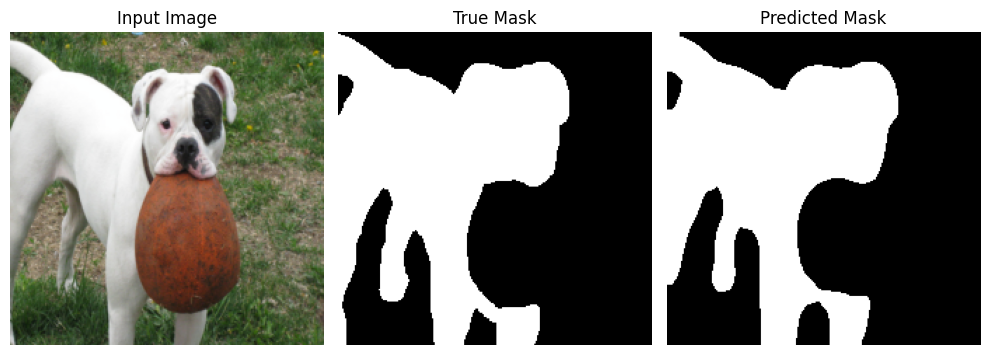

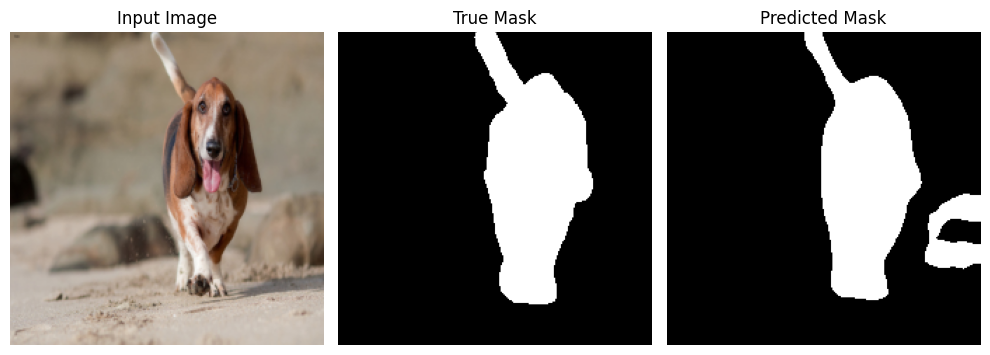

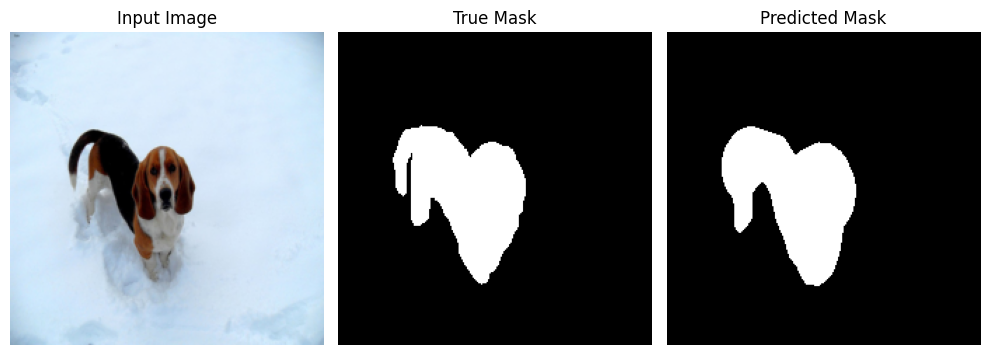

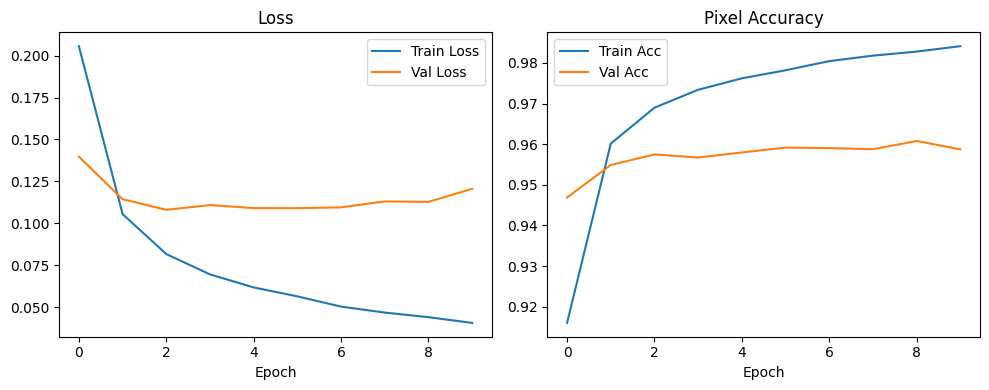

In [ ]:
# Cell 2 - PyTorch implementation of the tutorial pipeline on Oxford-IIIT Pet

import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.models.segmentation.deeplabv3 import DeepLabHead

# -----------------------------
# Config
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0
EPOCHS = 10
TRAIN_SUBSET = 800
VAL_SUBSET = 200
TEST_SUBSET = 1000
# -----------------------------
# Dataset
# -----------------------------
class OxfordPetSegDataset(Dataset):
    def __init__(self, root="./data", split="trainval", image_size=224, download=False):
        self.ds = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download,
        )
        self.image_size = image_size

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image, mask = self.ds[idx]

        image = TF.resize(image, [self.image_size, self.image_size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.image_size, self.image_size], interpolation=InterpolationMode.NEAREST)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        # Oxford-IIIT Pet trimap: treat non-background pixels as pet foreground
        mask = (mask != 2).long()

        return image, mask

trainval_full = OxfordPetSegDataset(split="trainval", image_size=IMG_SIZE, download=False)
test_dataset = OxfordPetSegDataset(split="test", image_size=IMG_SIZE, download=False)

indices = torch.randperm(len(trainval_full), generator=torch.Generator().manual_seed(seed)).tolist()
train_idx = indices[:TRAIN_SUBSET]
val_idx = indices[TRAIN_SUBSET:TRAIN_SUBSET + VAL_SUBSET]

train_dataset = Subset(trainval_full, train_idx)
val_dataset = Subset(trainval_full, val_idx)
test_dataset = Subset(test_dataset, range(1000))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Train subset:", len(train_dataset))
print("Val subset:", len(val_dataset))
print("Test set:", len(test_dataset))

# -----------------------------
# Model
# -----------------------------
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)
model.classifier = DeepLabHead(2048, 2)
if model.aux_classifier is not None:
    model.aux_classifier[4] = nn.Conv2d(256, 2, kernel_size=1)
model = model.to(device)
print("Model device:", next(model.parameters()).device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# -----------------------------
# Train / eval helpers
# -----------------------------
def pixel_accuracy_from_logits(logits, masks):
    preds = logits.argmax(dim=1)
    return (preds == masks).float().mean().item()

def run_epoch(loader, training=True):
    model.train(training)
    total_loss = 0.0
    total_acc = 0.0
    total = 0
    print("Using device:", device)
    print("Model device:", next(model.parameters()).device)
    print("Train batches:", len(train_loader))
    print("Val batches:", len(val_loader))

    images, masks = next(iter(train_loader))
    print("One batch image shape:", images.shape)
    print("One batch mask shape:", masks.shape)

    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        out = model(images)["out"]

    print("Forward pass output shape:", out.shape)
    for batch_idx, (images, masks) in enumerate(loader, start=1):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.set_grad_enabled(training):
            outputs = model(images)["out"]
            loss = criterion(outputs, masks)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_acc += pixel_accuracy_from_logits(outputs.detach(), masks) * bs
        total += bs
        if batch_idx % 1 == 0:
            mode = "Train" if training else "Val"
            print(f"{mode} batch {batch_idx}/{len(loader)}")
    return total_loss / total, total_acc / total

# -----------------------------
# Train
# -----------------------------
best_state = copy.deepcopy(model.state_dict())
best_val_acc = -1.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(val_loader, training=False)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)

# -----------------------------
# Test
# -----------------------------
test_loss, test_acc = run_epoch(test_loader, training=False)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

# -----------------------------
# Visualize predictions
# -----------------------------
images, masks = next(iter(test_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    preds = model(images)["out"].argmax(dim=1).cpu()

images = images.cpu()

for i in range(3):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("True Mask")
    plt.imshow(masks[i].numpy(), cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow(preds[i].numpy(), cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# -----------------------------
# Learning curves
# -----------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Pixel Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()


# Mask R-CNN

Using device: cuda
Train subset: 800
Val subset: 200
Test set: 1000
Creating Mask R-CNN model...
Model created. Replacing heads...
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Train batch 1/50
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap unique values: [1 2 3]
Trimap uniqu

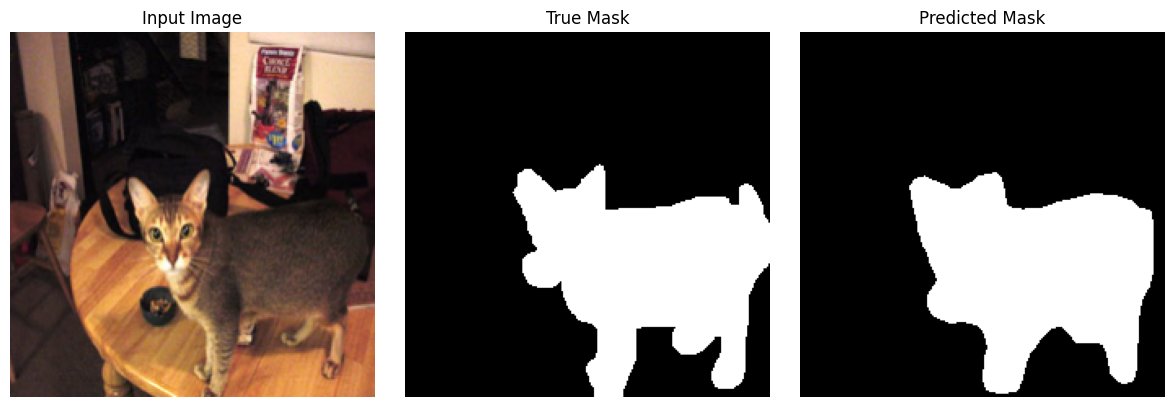

In [ ]:
# Cell 3 - Mask R-CNN on the same Oxford-IIIT Pet dataset

import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import functional as TF
from torchvision.transforms.functional import InterpolationMode
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# -----------------------------
# Config
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0
EPOCHS = 10
TRAIN_SUBSET = 800
VAL_SUBSET = 200
TEST_SUBSET = 1000
SCORE_THRESH = 0.5

# -----------------------------
# Dataset for instance segmentation
# -----------------------------
class OxfordPetMaskRCNNDataset(Dataset):
    def __init__(self, root="./data", split="trainval", image_size=224, download=False):
        self.ds = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download,
        )
        self.image_size = image_size

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        image, trimap = self.ds[idx]

        image = TF.resize(image, [self.image_size, self.image_size], interpolation=InterpolationMode.BILINEAR)
        trimap = TF.resize(trimap, [self.image_size, self.image_size], interpolation=InterpolationMode.NEAREST)

        image_tensor = TF.to_tensor(image)

        mask_np = np.array(trimap)
        mask_np = (mask_np != 2).astype(np.uint8)  # pet foreground

        obj_ids = np.array([1], dtype=np.int64) if mask_np.sum() > 0 else np.array([], dtype=np.int64)

        masks = []
        boxes = []
        labels = []
        areas = []

        if mask_np.sum() > 0:
            pos = np.where(mask_np)
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])

            boxes.append([xmin, ymin, xmax, ymax])
            masks.append(mask_np)
            labels.append(1)
            areas.append((xmax - xmin) * (ymax - ymin))

        if len(boxes) > 0:
            boxes_tensor = torch.as_tensor(boxes, dtype=torch.float32)
            labels_tensor = torch.as_tensor(labels, dtype=torch.int64)
            masks_tensor = torch.as_tensor(np.array(masks), dtype=torch.uint8)
            area_tensor = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd_tensor = torch.zeros((len(labels),), dtype=torch.int64)
        else:
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)
            masks_tensor = torch.zeros((0, self.image_size, self.image_size), dtype=torch.uint8)
            area_tensor = torch.zeros((0,), dtype=torch.float32)
            iscrowd_tensor = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_tensor,
            "labels": labels_tensor,
            "masks": masks_tensor,
            "image_id": torch.tensor([idx]),
            "area": area_tensor,
            "iscrowd": iscrowd_tensor,
        }
        # print("Trimap unique values:", np.unique(np.array(trimap)))
        return image_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))

trainval_full = OxfordPetMaskRCNNDataset(split="trainval", image_size=IMG_SIZE, download=False)
test_dataset = OxfordPetMaskRCNNDataset(split="test", image_size=IMG_SIZE, download=False)

indices = torch.randperm(len(trainval_full), generator=torch.Generator().manual_seed(seed)).tolist()
train_idx = indices[:TRAIN_SUBSET]
val_idx = indices[TRAIN_SUBSET:TRAIN_SUBSET + VAL_SUBSET]

train_dataset = Subset(trainval_full, train_idx)
val_dataset = Subset(trainval_full, val_idx)
test_dataset = Subset(test_dataset, range(TEST_SUBSET))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

print("Train subset:", len(train_dataset))
print("Val subset:", len(val_dataset))
print("Test set:", len(test_dataset))

# -----------------------------
# Model
# -----------------------------
print("Creating Mask R-CNN model...")

model = maskrcnn_resnet50_fpn(weights="DEFAULT")

print("Model created. Replacing heads...")

num_classes = 2  # background + pet
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

model = model.to(device)
optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad], lr=0.005, momentum=0.9, weight_decay=0.0005)

# -----------------------------
# Train
# -----------------------------
def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    total_batches = 0

    for batch_idx, (images, targets) in enumerate(loader, start=1):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()
        total_batches += 1

        print(f"Train batch {batch_idx}/{len(loader)}")

    return total_loss / total_batches

best_state = copy.deepcopy(model.state_dict())
best_val_iou = -1.0

# -----------------------------
# Simple test metric: best-mask IoU
# -----------------------------
def mask_iou(pred_mask, true_mask, eps=1e-6):
    pred_mask = pred_mask.astype(np.uint8)
    true_mask = true_mask.astype(np.uint8)
    intersection = (pred_mask & true_mask).sum()
    union = (pred_mask | true_mask).sum()
    return (intersection + eps) / (union + eps)

def evaluate_loader(loader):
    model.eval()
    ious = []

    with torch.no_grad():
        for images, targets in loader:
            image = images[0].to(device)
            target = targets[0]
            true_mask = target["masks"][0].numpy() if target["masks"].shape[0] > 0 else None

            outputs = model([image])[0]

            if true_mask is None:
                continue

            if len(outputs["scores"]) == 0 or outputs["scores"][0].item() < SCORE_THRESH:
                ious.append(0.0)
                continue

            pred_mask = (outputs["masks"][0, 0].cpu().numpy() > 0.5).astype(np.uint8)
            ious.append(mask_iou(pred_mask, true_mask))

    return float(np.mean(ious)) if len(ious) > 0 else 0.0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(train_loader)
    val_iou = evaluate_loader(val_loader)
    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Mask IoU: {val_iou:.4f}")

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)

test_iou = evaluate_loader(test_loader)
print(f"Test Mask IoU: {test_iou:.4f}")

# -----------------------------
# Visualize predictions
# -----------------------------
model.eval()
images, targets = next(iter(test_loader))
image = images[0].to(device)
target = targets[0]

with torch.no_grad():
    output = model([image])[0]

img = image.cpu().permute(1, 2, 0).numpy()
img = np.clip(img, 0, 1)
true_mask = target["masks"][0].numpy() if target["masks"].shape[0] > 0 else np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Input Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("True Mask")
plt.imshow(true_mask, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
if len(output["scores"]) > 0:
    pred_mask = (output["masks"][0, 0].cpu().numpy() > 0.5).astype(np.uint8)
    plt.imshow(pred_mask, cmap="gray")
else:
    plt.imshow(np.zeros_like(true_mask), cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()
